# Small Parameter Sensitivity Check

This notebook checks whether the main Score B result is unusually dependent on the chosen rolling-window length, Mondrian grid, or shrinkage value. It is separate from `conformal_prediction.ipynb`, which remains the notebook for the final reported experiment.

## Leakage-free design

Only the first 15 retained surfaces are used here. Surfaces 0--6 provide the initial history and surfaces 7--14 form a common development-validation period. The final evaluation surfaces 15--45 are never loaded into the sensitivity calculations.

The GNO prediction and the deterministic 20% context/target mask are computed once per development surface and reused for every configuration. This ensures that only the calibration parameters change. The comparison uses pre-projection Score B coverage and IV band width because the purpose is to inspect the rolling and Mondrian calibration choices, not the financial shape-adjustment routine. Each reported mean gives equal weight to each of the eight validation surfaces.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

# Find the repository root whether Jupyter starts here or from a parent folder.
_start = Path.cwd().resolve()
REPO_ROOT = next(
    (path for path in (_start, *_start.parents)
     if (path / 'volatility_smoothing').is_dir()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError('Could not locate the thesis repository root')
sys.path.insert(0, str(REPO_ROOT))

from volatility_smoothing.utils.options_data import WRDSOptionsDataset
from volatility_smoothing.utils.train.dataset import GNOOptionsDataset
from volatility_smoothing.utils.train.loss import Loss
from volatility_smoothing.utils.train import misc
from volatility_smoothing.conformal.evaluation import (
    build_masked_gno_input,
    read_masked_gno_output,
)
from volatility_smoothing.conformal.mondrian import MondrianConformal

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (11, 5)
print(f'Repository root: {REPO_ROOT}')

Repository root: /Users/anighot/Documents/Thesis_New/conformal-prediction-thesis


## Fixed inputs and configurations

The reference configuration is the one already used in the final notebook: window 5, a $4\times4$ Mondrian grid, and shrinkage 0.3. One parameter is changed at a time, giving seven configurations rather than a full Cartesian grid. The 20% target fraction and masking seed are held fixed.

In [2]:
CHECKPOINT_PATH = REPO_ROOT / 'volatility_smoothing/train/store/9448705/checkpoints/checkpoint_final.pt'
DATA_DIR = REPO_ROOT / 'volatility_smoothing/data/openbb/spx'
CACHE_DIR = Path.home() / '.cache/opds_rolling_window'
DEVICE = torch.device('cpu')

ALPHA = 0.10
TARGET_COVERAGE = 1.0 - ALPHA
TARGET_FRACTION = 0.20
MASK_SEED = 2026
MASK_BINS_RHO = 4
MASK_BINS_Z = 4
RHO_RANGE = (0.01, 1.0)
Z_RANGE = (-1.5, 0.5)
MIN_SAMPLES_PER_BIN = 10
MIN_VEGA_WEIGHT = 1.0
DEVELOPMENT_SIZE = 15
VALIDATION_START = 7
DEVELOPMENT_INDICES = list(range(DEVELOPMENT_SIZE))
VALIDATION_INDICES = list(range(VALIDATION_START, DEVELOPMENT_SIZE))
FINAL_TEST_START = DEVELOPMENT_SIZE

EXCLUDED_COLLECTION_DATES = (
    '2025-12-21', '2025-12-25', '2025-12-27', '2026-01-03',
    '2026-02-14', '2026-06-27', '2026-07-03', '2026-07-18',
    '2026-08-08', '2026-08-15',
)

CONFIGURATIONS = [
    dict(label='Reference', window=5, bins=4, shrinkage=0.3, varied='none'),
    dict(label='Window 3', window=3, bins=4, shrinkage=0.3, varied='window'),
    dict(label='Window 7', window=7, bins=4, shrinkage=0.3, varied='window'),
    dict(label='Grid 3x3', window=5, bins=3, shrinkage=0.3, varied='grid'),
    dict(label='Grid 5x5', window=5, bins=5, shrinkage=0.3, varied='grid'),
    dict(label='Shrinkage 0.1', window=5, bins=4, shrinkage=0.1, varied='shrinkage'),
    dict(label='Shrinkage 0.5', window=5, bins=4, shrinkage=0.5, varied='shrinkage'),
]

assert max(item['window'] for item in CONFIGURATIONS) <= VALIDATION_START
assert len({item['label'] for item in CONFIGURATIONS}) == len(CONFIGURATIONS)
assert max(VALIDATION_INDICES) < FINAL_TEST_START
assert CHECKPOINT_PATH.is_file(), CHECKPOINT_PATH
assert DATA_DIR.is_dir(), DATA_DIR

os.environ['OPDS_CACHE_DIR'] = str(CACHE_DIR)
os.environ['OPDS_WRDS_DATA_DIR'] = str(DATA_DIR)
os.environ['OPDS_FILE_MODE'] = 'combined'

pd.DataFrame(CONFIGURATIONS)

,label,window,bins,shrinkage,varied
0,Reference,5,4,0.3,none
1,Window 3,3,4,0.3,window
2,Window 7,7,4,0.3,window
3,Grid 3x3,5,3,0.3,grid
4,Grid 5x5,5,5,0.3,grid
5,Shrinkage 0.1,5,4,0.1,shrinkage
6,Shrinkage 0.5,5,4,0.5,shrinkage


## Conformal helper functions

These functions reproduce the exact finite-sample order statistic and the Score B weighting used in the final notebook.

In [3]:
def conformal_order_statistic(scores, alpha=ALPHA):
    values = np.asarray(scores, dtype=float).reshape(-1)
    if values.size == 0:
        raise ValueError('Cannot calibrate on an empty score array')
    rank = min(values.size, int(np.ceil((values.size + 1) * (1 - alpha))))
    return float(np.partition(values, rank - 1)[rank - 1])


class ExactOrderStatisticMondrian(MondrianConformal):
    def calibrate(self, rho, z, scores):
        rho = np.asarray(rho, dtype=float).reshape(-1)
        z = np.asarray(z, dtype=float).reshape(-1)
        scores = np.asarray(scores, dtype=float).reshape(-1)
        if not (rho.size == z.size == scores.size):
            raise ValueError('Calibration coordinates and scores must have equal length')

        for row in self.bins:
            for bin_obj in row:
                bin_obj.scores = []

        for rho_i, z_i, score_i in zip(rho, z, scores):
            i, j = self._find_bin_indices(rho_i, z_i)
            self.bins[i][j].scores.append(float(score_i))

        self.global_quantile = conformal_order_statistic(scores, self.alpha)
        for row in self.bins:
            for bin_obj in row:
                if len(bin_obj.scores) >= self.min_samples_per_bin:
                    q_raw = conformal_order_statistic(bin_obj.scores, self.alpha)
                    bin_obj.quantile = (
                        self.shrinkage * self.global_quantile
                        + (1 - self.shrinkage) * q_raw
                    )
                else:
                    bin_obj.quantile = self.global_quantile
        self._calibrated = True


def score_b_weights(rho, z, iv, min_weight=MIN_VEGA_WEIGHT):
    rho = np.asarray(rho, dtype=float).reshape(-1)
    z = np.asarray(z, dtype=float).reshape(-1)
    iv = np.maximum(np.asarray(iv, dtype=float).reshape(-1), 1e-8)
    d1 = -z / iv + 0.5 * iv * rho
    vega = rho * np.exp(-0.5 * d1 ** 2) / np.sqrt(2 * np.pi)
    mean_vega = max(float(vega.mean()), 1e-12)
    return np.maximum(vega / mean_vega, min_weight)


def score_b_bands(iv_pred, weights, quantiles):
    iv_pred = np.asarray(iv_pred, dtype=float).reshape(-1)
    weights = np.asarray(weights, dtype=float).reshape(-1)
    half_width = np.asarray(quantiles, dtype=float) / weights
    lower = np.maximum(iv_pred - half_width, 1e-4)
    upper = iv_pred + half_width
    return lower, upper


assert conformal_order_statistic(np.arange(10), 0.1) == 9.0
_test_weights = score_b_weights(
    np.array([0.2, 0.4]), np.array([-0.2, 0.1]), np.array([0.2, 0.25]))
assert np.all(np.isfinite(_test_weights)) and np.all(_test_weights >= 1.0)
print('Conformal helpers verified')

Conformal helpers verified


## Load the filtered data and pretrained GNO

The same ten non-regular-session collection dates used in the final notebook are excluded. The assertions prevent the sensitivity study from silently running on a different dataset.

In [4]:
dataset = WRDSOptionsDataset()
raw_n_surfaces = len(dataset)
raw_dates = dataset.quote_datetimes.normalize()
excluded_dates = pd.DatetimeIndex(pd.to_datetime(EXCLUDED_COLLECTION_DATES))
keep_mask = ~raw_dates.isin(excluded_dates)

assert raw_n_surfaces == 56, f'Expected 56 raw surfaces, found {raw_n_surfaces}'
assert excluded_dates.difference(raw_dates).empty

dataset.file_paths = [path for path, keep in zip(dataset.file_paths, keep_mask) if keep]
dataset.quote_datetimes = dataset.quote_datetimes[keep_mask]
assert len(dataset) == 46, f'Expected 46 retained surfaces, found {len(dataset)}'

# The sensitivity study is restricted to indices 0--14.
development_dates = dataset.quote_datetimes[:DEVELOPMENT_SIZE]
assert len(development_dates) == DEVELOPMENT_SIZE

model, _ = misc.load_checkpoint(str(CHECKPOINT_PATH), device=DEVICE)
model.to(DEVICE)
model.eval()
gno_dataset = GNOOptionsDataset(dataset)
dev_loss = Loss(step_r=0.01, step_z=0.01)

print(f'Raw surfaces: {raw_n_surfaces}')
print(f'Retained surfaces: {len(dataset)}')
print(f'Development range: {development_dates[0]} to {development_dates[-1]}')
print(f'Validation indices: {VALIDATION_INDICES}')

Raw surfaces: 56
Retained surfaces: 46
Development range: 2025-12-11 00:00:00 to 2026-02-17 00:00:00
Validation indices: [7, 8, 9, 10, 11, 12, 13, 14]


## Cache the 15 development predictions

This is the only cell that calls the GNO. It predicts each held-out target set once. No final evaluation surface is accessed.

In [5]:
surface_cache = {}

for idx in DEVELOPMENT_INDICES:
    assert idx < FINAL_TEST_START
    data = gno_dataset[idx]
    context_data, target_data, input_dict, aux = build_masked_gno_input(
        data, dev_loss, surface_index=idx,
        target_fraction=TARGET_FRACTION, mask_seed=MASK_SEED,
        n_bins_rho=MASK_BINS_RHO, n_bins_z=MASK_BINS_Z,
        rho_range=RHO_RANGE, z_range=Z_RANGE,
    )
    input_dict = {
        key: value.to(DEVICE) if torch.is_tensor(value) else value
        for key, value in input_dict.items()
    }

    with torch.no_grad():
        output = model(**input_dict)
    iv_predict, *_ = read_masked_gno_output(output, aux)

    rho = target_data['r'].cpu().numpy().reshape(-1)
    z = target_data['z'].cpu().numpy().reshape(-1)
    iv_pred = iv_predict.cpu().numpy().reshape(-1)
    iv_market = target_data['implied_volatility'].cpu().numpy().reshape(-1)
    # Exposé Eq. (2) uses market-IV Vega for calibration scores, while
    # Eq. (6) uses predicted-IV Vega for prediction-band widths.
    score_weights = score_b_weights(rho, z, iv_market)
    band_weights = score_b_weights(rho, z, iv_pred)
    scores = score_weights * np.abs(iv_pred - iv_market)

    assert len(rho) == int(target_data.num_nodes)
    assert np.all(np.isfinite(scores))
    surface_cache[idx] = {
        'date': pd.Timestamp(data['quote_datetime']),
        'n_context': int(context_data.num_nodes),
        'n_target': int(target_data.num_nodes),
        'rho': rho,
        'z': z,
        'iv_pred': iv_pred,
        'iv_market': iv_market,
        'score_weights': score_weights,
        'band_weights': band_weights,
        'scores': scores,
    }
    print(
        f'[{idx:2d}] {data["quote_datetime"]}: '
        f'context={context_data.num_nodes}, target={target_data.num_nodes}'
    )

assert set(surface_cache) == set(DEVELOPMENT_INDICES)
print('Development predictions cached')

[ 0] 2025-12-11 00:00:00: context=7174, target=1792
[ 1] 2025-12-23 00:00:00: context=6943, target=1734
[ 2] 2025-12-24 00:00:00: context=7053, target=1763
[ 3] 2025-12-26 00:00:00: context=7026, target=1756
[ 4] 2026-01-02 00:00:00: context=7188, target=1799
[ 5] 2026-01-06 00:00:00: context=7294, target=1822
[ 6] 2026-01-07 00:00:00: context=7329, target=1835
[ 7] 2026-01-09 00:00:00: context=7386, target=1848
[ 8] 2026-01-14 00:00:00: context=7254, target=1814
[ 9] 2026-01-15 00:00:00: context=7269, target=1817
[10] 2026-01-23 00:00:00: context=7710, target=1926
[11] 2026-01-29 00:00:00: context=7480, target=1871
[12] 2026-01-30 00:00:00: context=7453, target=1863
[13] 2026-02-11 00:00:00: context=7411, target=1853
[14] 2026-02-17 00:00:00: context=7291, target=1823
Development predictions cached


## Walk-forward sensitivity calculation

For each validation surface, the quantiles are computed from only the immediately preceding $K$ surfaces. The current surface enters the history only for later dates, exactly as in a walk-forward evaluation.

In [6]:
def evaluate_configuration(config):
    rows = []
    window = int(config['window'])
    bins = int(config['bins'])
    shrinkage = float(config['shrinkage'])

    for idx in VALIDATION_INDICES:
        history_indices = list(range(idx - window, idx))
        assert len(history_indices) == window
        assert min(history_indices) >= 0
        assert max(history_indices) < idx < FINAL_TEST_START

        rho_cal = np.concatenate([surface_cache[i]['rho'] for i in history_indices])
        z_cal = np.concatenate([surface_cache[i]['z'] for i in history_indices])
        scores_cal = np.concatenate([surface_cache[i]['scores'] for i in history_indices])
        q_global = conformal_order_statistic(scores_cal)

        mondrian = ExactOrderStatisticMondrian(
            n_bins_rho=bins, n_bins_z=bins,
            rho_range=RHO_RANGE, z_range=Z_RANGE,
            alpha=ALPHA, min_samples_per_bin=MIN_SAMPLES_PER_BIN,
            shrinkage=shrinkage,
        )
        mondrian.calibrate(rho_cal, z_cal, scores_cal)

        current = surface_cache[idx]
        q_mondrian = mondrian.get_quantiles(current['rho'], current['z'])
        q_global_array = np.full(current['n_target'], q_global)
        lo_global, hi_global = score_b_bands(
            current['iv_pred'], current['band_weights'], q_global_array)
        lo_mondrian, hi_mondrian = score_b_bands(
            current['iv_pred'], current['band_weights'], q_mondrian)

        market = current['iv_market']
        coverage_global = np.mean((market >= lo_global) & (market <= hi_global))
        coverage_mondrian = np.mean((market >= lo_mondrian) & (market <= hi_mondrian))
        width_global = np.mean(hi_global - lo_global)
        width_mondrian = np.mean(hi_mondrian - lo_mondrian)

        rows.append({
            'configuration': config['label'],
            'varied_parameter': config['varied'],
            'window': window,
            'bins': f'{bins}x{bins}',
            'shrinkage': shrinkage,
            'surface_idx': idx,
            'date': current['date'],
            'history_indices': tuple(history_indices),
            'n_calibration_scores': len(scores_cal),
            'n_target': current['n_target'],
            'coverage_global_pre': coverage_global,
            'coverage_mondrian_pre': coverage_mondrian,
            'mean_width_global_pre': width_global,
            'mean_width_mondrian_pre': width_mondrian,
        })

    return pd.DataFrame(rows)


def summarize_surface_weighted(surface_results):
    summary = (
        surface_results.groupby(
            ['configuration', 'varied_parameter', 'window', 'bins', 'shrinkage'],
            sort=False, as_index=False,
        )
        .agg(
            n_validation_surfaces=('surface_idx', 'nunique'),
            mean_coverage_global=('coverage_global_pre', 'mean'),
            mean_coverage_mondrian=('coverage_mondrian_pre', 'mean'),
            sd_coverage_mondrian=('coverage_mondrian_pre', 'std'),
            below_target_surfaces=('coverage_mondrian_pre', lambda x: int((x < TARGET_COVERAGE).sum())),
            mean_width_global=('mean_width_global_pre', 'mean'),
            mean_width_mondrian=('mean_width_mondrian_pre', 'mean'),
        )
    )
    summary['absolute_coverage_gap'] = (
        summary['mean_coverage_mondrian'] - TARGET_COVERAGE
    ).abs()
    return summary

print('Sensitivity functions ready')

Sensitivity functions ready


In [7]:
surface_results = pd.concat(
    [evaluate_configuration(config) for config in CONFIGURATIONS],
    ignore_index=True,
)
summary = summarize_surface_weighted(surface_results)

assert len(surface_results) == len(CONFIGURATIONS) * len(VALIDATION_INDICES)
assert summary['n_validation_surfaces'].eq(len(VALIDATION_INDICES)).all()
assert surface_results['surface_idx'].max() < FINAL_TEST_START
assert surface_results[['coverage_global_pre', 'coverage_mondrian_pre']].apply(
    lambda column: column.between(0, 1).all()).all()
assert (surface_results[['mean_width_global_pre', 'mean_width_mondrian_pre']] >= 0).all().all()
assert np.isfinite(summary.select_dtypes(include=[np.number]).to_numpy()).all()

reference = summary.loc[summary['configuration'].eq('Reference')].iloc[0]
summary['coverage_change_vs_reference_pp'] = 100 * (
    summary['mean_coverage_mondrian'] - reference['mean_coverage_mondrian']
)
summary['width_change_vs_reference_pct'] = 100 * (
    summary['mean_width_mondrian'] / reference['mean_width_mondrian'] - 1
)

display_columns = [
    'configuration', 'window', 'bins', 'shrinkage',
    'mean_coverage_mondrian', 'sd_coverage_mondrian',
    'below_target_surfaces', 'mean_width_mondrian',
    'coverage_change_vs_reference_pp', 'width_change_vs_reference_pct',
]
display(
    summary[display_columns].style
    .format({
        'mean_coverage_mondrian': '{:.2%}',
        'sd_coverage_mondrian': '{:.2%}',
        'mean_width_mondrian': '{:.5f}',
        'coverage_change_vs_reference_pp': '{:+.2f}',
        'width_change_vs_reference_pct': '{:+.1f}%',
    })
)
print('All checks passed: only development indices 0--14 were used.')

,configuration,window,bins,shrinkage,mean_coverage_mondrian,sd_coverage_mondrian,below_target_surfaces,mean_width_mondrian,coverage_change_vs_reference_pp,width_change_vs_reference_pct
0,Reference,5,4x4,0.300000,91.11%,2.68%,2,0.02831,+0.00,+0.0%
1,Window 3,3,4x4,0.300000,91.30%,2.68%,3,0.02864,+0.19,+1.2%
2,Window 7,7,4x4,0.300000,90.79%,2.54%,2,0.02802,-0.32,-1.0%
3,Grid 3x3,5,3x3,0.300000,90.21%,2.52%,3,0.02817,-0.91,-0.5%
4,Grid 5x5,5,5x5,0.300000,90.56%,2.51%,3,0.02802,-0.55,-1.0%
5,Shrinkage 0.1,5,4x4,0.100000,89.79%,3.03%,4,0.02794,-1.33,-1.3%
6,Shrinkage 0.5,5,4x4,0.500000,91.39%,2.78%,2,0.02868,+0.27,+1.3%


All checks passed: only development indices 0--14 were used.


## Comparison figures

Coverage and width are shown separately so the labels remain readable. The dashed line is the 90% target; it is not a pass/fail requirement for every individual validation surface.

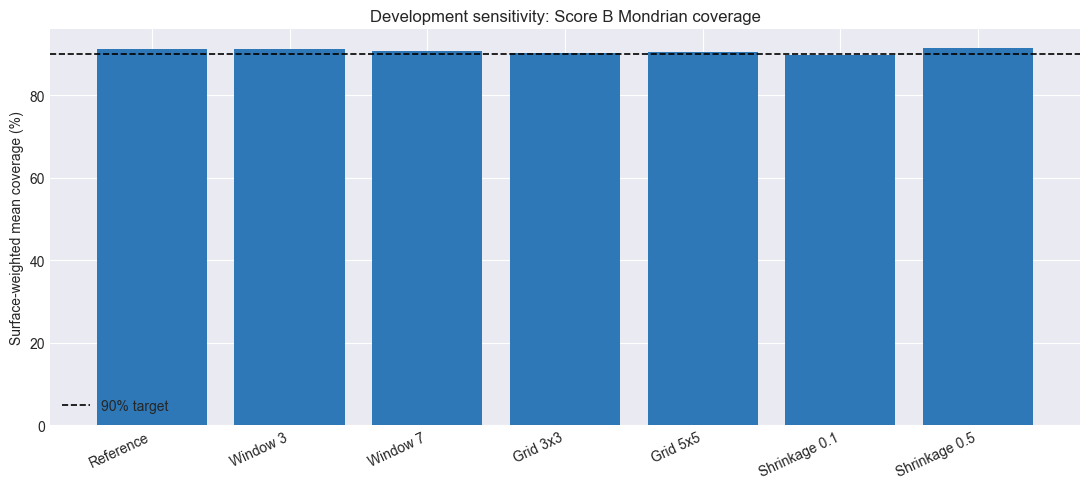

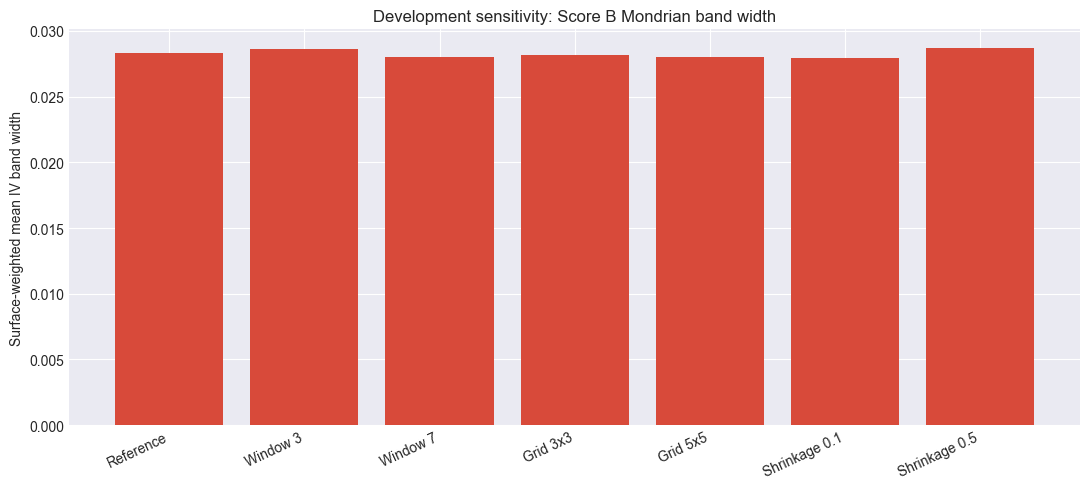

In [8]:
labels = summary['configuration'].tolist()
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x, 100 * summary['mean_coverage_mondrian'], color='#2f78b7')
ax.axhline(100 * TARGET_COVERAGE, color='black', linestyle='--', linewidth=1.2, label='90% target')
ax.set_xticks(x, labels, rotation=25, ha='right')
ax.set_ylabel('Surface-weighted mean coverage (%)')
ax.set_title('Development sensitivity: Score B Mondrian coverage')
ax.legend(loc='best')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x, summary['mean_width_mondrian'], color='#d84a3a')
ax.set_xticks(x, labels, rotation=25, ha='right')
ax.set_ylabel('Surface-weighted mean IV band width')
ax.set_title('Development sensitivity: Score B Mondrian band width')
fig.tight_layout()
plt.show()

## How to interpret the output

Use the reference row as the main comparison. Small changes in coverage and width across the nearby configurations support the statement that the conclusion is not driven by one exact setting. Large changes should be reported as sensitivity and discussed before altering the final notebook.

This notebook does not automatically choose a new configuration and must not be used to tune parameters on surfaces 15--45. The final test results remain those produced by `conformal_prediction.ipynb`.